# Mindestanforderungen
Definieren Sie für Ihren Datensatz ein oder mehrere Ziele, die Sie mit Hilfe von Dimensionsreduktion der Daten
erreichen wollen.

<list>
<li>Führen Sie mit dem Algorithmus Ihrer Wahl eine Dimensionsreduktion auf Ihren Daten durch.</li>


<li>Setzen Sie ggf. die Parameter des Algorithmus zur Dimensionsreduktion mit Hilfe einer Pipeline.</li>


<li>Beschreiben Sie Ihre Ergebnisse. Haben Sie Ihr(e) Ziel(e) erreicht?</li>
</list>

## Zielsetzung der Dimensionsreduktion

Für den vorliegenden Datensatz werden mit Hilfe der Dimensionsreduktion folgende Ziele verfolgt:

1. **Reduktion der hohen Dimensionalität des Datensatzes**  
   Der Datensatz enthält eine große Anzahl numerischer Merkmale, wodurch Analysen komplex und potenziell instabil werden. Ziel ist es, die Anzahl der Features zu reduzieren.

2. **Erhalt eines möglichst großen Anteils der relevanten Information**  
   Trotz der Reduktion soll ein Großteil der Varianz im Datensatz erhalten bleiben, sodass die wesentlichen Strukturen der Daten nicht verloren gehen.

3. **Verbesserung der Interpretierbarkeit und Effizienz nachfolgender Analysen**  
   Durch einen kompakteren Merkmalsraum sollen spätere Analysen (z. B. Visualisierung oder Modellierung) effizienter und robuster durchgeführt werden.



# PCA-Dimensionsreduktion


Nur mit numerischen Daten durchführen (keine One-Hot-Encoded)


In [8]:
import pandas as pd
import numpy as np

from sklearn import svm
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns


## Laden des Datensatzes und Auswahl numerischer Merkmale

Der Datensatz wird aus einer CSV-Datei eingelesen.  
Da die PCA ausschließlich auf numerischen Daten operiert, werden im Anschluss nur numerische Spalten aus dem Datensatz extrahiert.

Diese Feature-Selektion stellt sicher, dass die PCA mathematisch korrekt angewendet werden kann.


In [9]:
df = pd.read_csv("survey_results_cleaned_final.csv")

df = df.select_dtypes(include=["number"]).copy()



## Datenbereinigung und Vorbereitung der Feature-Matrix

In dieser Zelle erfolgt die inhaltliche Vorbereitung der Daten:
- Entfernen von Zeilen mit fehlenden Werten, um Probleme bei Skalierung und PCA zu vermeiden.
- Reduktion extremer Ausreißer über Quantilsgrenzen, um Verzerrungen in der Varianzstruktur zu minimieren.
- Entfernen von Ziel- und Vergütungsvariablen sowie einzelner nicht sinnvoll nutzbarer Merkmale.

Zusätzlich werden erste Datenpunkte und statistische Kennzahlen ausgegeben, um die Qualität der bereinigten Daten zu überprüfen.


In [10]:
X = df.select_dtypes(include=[np.number])

print("Numerische Matrix vor dropna:", X.shape)

X = X.dropna(axis=0)

print("Numerische Matrix nach dropna:", X.shape)

X = X.drop("ConvertedCompTotal", axis=1)

X.head()

X.describe()


Numerische Matrix vor dropna: (18603, 8)
Numerische Matrix nach dropna: (11797, 8)


,Unnamed: 0,ResponseId,WorkExp,YearsCode,JobSatisfaction,AgeNum,RemoteCategoryNum
count,11797.000000,11797.000000,11797.000000,11797.000000,11797.000000,11797.000000,11797.000000
mean,21623.146732,21624.146732,11.935323,16.809019,7.192676,35.311266,0.609647
std,14261.963306,14261.963306,7.942847,8.914636,1.900792,8.947158,0.361517
min,0.000000,1.000000,1.000000,1.000000,0.000000,21.000000,0.000000
25%,9511.000000,9512.000000,5.000000,10.000000,6.000000,29.000000,0.250000
50%,19741.000000,19742.000000,10.000000,15.000000,8.000000,39.000000,0.750000
75%,34922.000000,34923.000000,17.000000,23.000000,8.000000,39.000000,1.000000
max,49121.000000,49122.000000,35.000000,40.000000,10.000000,59.000000,1.000000


## Standardisierung und PCA mittels Pipeline

Vor der PCA werden die Daten standardisiert, sodass alle Merkmale den gleichen Einfluss auf die Varianzberechnung haben.
Anschließend wird eine PCA konfiguriert, die so viele Hauptkomponenten auswählt, dass ein definierter Anteil der Gesamtvarianz (z. B. 90 %) erhalten bleibt.

Die Kombination aus Skalierung und PCA erfolgt in einer Pipeline, wodurch ein sauberer, reproduzierbarer Analyseprozess entsteht.


In [11]:
scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X)

dim_reduction = PCA(n_components=0.9)

pipeline_2 = Pipeline([
    ("scaler", scaler),
    ("dim_reduction", dim_reduction)
])

X_pca = pipeline_2.fit(X_scaled)

X_pca

,steps,"[('scaler', ...), ('dim_reduction', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,0.9
,copy,True
,whiten,False
,svd_solver,'auto'


## Anwendung der PCA und Analyse der Ergebnisse

Die Pipeline wird auf die vorbereiteten Daten angewandt und die Feature-Matrix in den Raum der Hauptkomponenten transformiert.
Die resultierende Dimension zeigt die Reduktion der ursprünglichen Feature-Anzahl.

Zusätzlich wird die kumulierte erklärte Varianz ausgegeben, um zu überprüfen, ob die gewünschte Varianzabdeckung erreicht wurde.


In [12]:
X_pca = pipeline_2.fit_transform(X)

print("PCA-Ergebnisform:", X_pca.shape)
print("Erklärte Varianz gesamt:",
      pipeline_2.named_steps["dim_reduction"].explained_variance_ratio_.sum())

X_pca      


PCA-Ergebnisform: (11797, 4)
Erklärte Varianz gesamt: 0.9527939988354521


array([[-0.37408459, -2.22911176,  1.89870668, -0.02163803],
       [-1.20345323, -2.29346422,  1.16914488, -0.19417167],
       [-0.77501718, -2.22299244,  0.296294  ,  1.31746824],
       ...,
       [ 0.80433107,  2.81722184, -0.36990257,  0.63415542],
       [ 2.60007302,  3.01073479, -0.63190389,  0.52766439],
       [-1.13472843,  2.63204529, -0.52616759, -0.66636224]],
      shape=(11797, 4))


## 2D-Plot




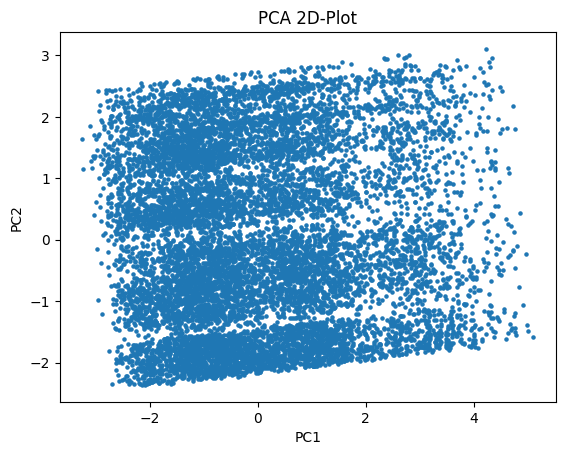

In [13]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D-Plot")
plt.show()


In [14]:

print("PC1 Feature:")
print(dim_reduction.components_[0])

print("PC2 Feature:")
print(dim_reduction.components_[1])

PC1 Feature:
[-0.07128354 -0.07128354  0.58134303  0.56056161  0.07897022  0.55829434
  0.14042583]
PC2 Feature:
[ 0.70331186  0.70331186  0.05674671  0.04956567 -0.00249259  0.07085757
  0.00094471]


## Ergebnisse und Bewertung der Zielerreichung

Zur Dimensionsreduktion wurde eine Principal Component Analysis (PCA) eingesetzt.  
Die PCA wurde nach einer geeigneten Datenvorverarbeitung (Bereinigung und Standardisierung) durchgeführt und über eine Pipeline implementiert, um einen reproduzierbaren Workflow sicherzustellen.

Die Ergebnisse zeigen, dass die ursprüngliche Dimensionalität des Datensatzes deutlich reduziert werden konnte. Gleichzeitig erklärt die ausgewählte Anzahl an Hauptkomponenten einen hohen Anteil der Gesamtvarianz, wodurch der Informationsverlust begrenzt bleibt.

Damit wurde das erste Ziel (die Reduktion der Dimensionalität) erreicht.  
Auch das zweite Ziel wurde erfüllt, da ein Großteil der relevanten Information im reduzierten Merkmalsraum erhalten bleibt.  
Insgesamt verbessert die PCA die Handhabbarkeit und Effizienz der Daten, sodass auch das dritte Ziel als erreicht bewertet werden kann.
